<a href="https://colab.research.google.com/github/luisvildozo/catastro-frutales/blob/main/Random_Forest_frutales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CLASIFICACIÓN SUPERVISADA PARA ÁREAS FRUTALES EN LA PROVINCIA DE QUILLOTA**

# 01. Cargar capas

In [ ]:
# Instalar geemap para visualización interactiva de mapas
# !pip install geemap -q
import ee
import geemap

# Iniciar la solicitud de token OAuth 2.0
ee.Authenticate()
ee.Initialize(project='luisvildozo1')

In [ ]:
# Conectar con Google Drive
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Leer la capas de ODEPA desde mi Google Drive
import geopandas as gpd

ruta_minagri = "/content/drive/MyDrive/Colab Notebooks/Evaluacion3_SIG/INPUTS/minagri.gpkg"

minagri = gpd.read_file(ruta_minagri)

In [ ]:
# Reproyectar a WGS84 (para evitar problemas posteriores en el procesamiento)
minagri = minagri.to_crs(4326)

In [ ]:
# Convertir capa de ODEPA a Earth Engine y leer el archivo de FTW desde los Assets de GEE
minagri_ee = geemap.gdf_to_ee(minagri)
ftw_ee = ee.FeatureCollection("projects/luisvildozo1/assets/ftw2")

# 02. Procesamiento satelital y cálculo de índices

In [ ]:
# Obtención de la colección de imágenes satelitales de Sentinel-2
s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterDate("2024-01-01", "2025-12-31")
    .filterBounds(minagri_ee)
    .filter(
        ee.Filter.lt(
            'CLOUDY_PIXEL_PERCENTAGE',
            10
        )
    )
)

In [ ]:
# Creación de los índices espectrales con la colección de imágenes satelitales
def add_indices(img):

    ndvi = img.normalizedDifference(
        ['B8','B4']
    ).rename('NDVI')

    ndwi = img.normalizedDifference(
        ['B8','B11']
    ).rename('NDWI')

    evi = img.expression(
        '2.5*((nir-red)/(nir+6*red-7.5*blue+1))',
        {
            'nir': img.select('B8'),
            'red': img.select('B4'),
            'blue': img.select('B2')
        }
    ).rename('EVI')

    ndre = img.normalizedDifference(
        ['B8','B5']
    ).rename('NDRE')

    return img.addBands(
        [ndvi, ndwi, evi, ndre]
    )

In [ ]:
# Añadir los índices creados a la colección de imágenes como bandas nuevas
s2 = s2.map(add_indices)

# 03. Construir variables mensuales

In [ ]:
# Obtención de la mediana de cada índice en las parcelas iniciales
months = range(1,13)

images = []

for m in months:

    monthly = (
        s2
        .filter(
            ee.Filter.calendarRange(
                m,
                m,
                'month'
            )
        )
        .select(
            ['NDVI','NDWI','EVI', 'NDRE']
        )
        .median()
        .rename([
            f'NDVI_{m:02d}',
            f'NDWI_{m:02d}',
            f'EVI_{m:02d}',
            f'NDRE_{m:02d}'
        ])
    )

    images.append(monthly)

In [ ]:
# Apilar las variables y rellenar los píxels nulos para evitar errores posteriores
feature_stack = ee.Image.cat(images)

feature_stack = feature_stack.unmask(-9999)

# 04. Extraer variables para el entrenamiento

In [ ]:
# Extraer los datos obtenidos para el posterior entrenamiento y filtro/eliminación de los registros incompletos
training = feature_stack.reduceRegions(
    collection=minagri_ee,
    reducer=ee.Reducer.mean(),
    scale=10
)

training = training.filter(
    ee.Filter.notNull(
        feature_stack.bandNames()
    )
)

In [ ]:
# Convertir en lista de variables
variables = feature_stack.bandNames()

# 05. Entrenar modelo Random Forest

In [ ]:
# Definición del número de árboles aleatorios del modelo y de la variable de respuesta
classifier = ee.Classifier.smileRandomForest(
    numberOfTrees=500
).train(
    features=training,
    classProperty='cultivo',
    inputProperties=variables
)

### Gráficas de índices por especie y mes

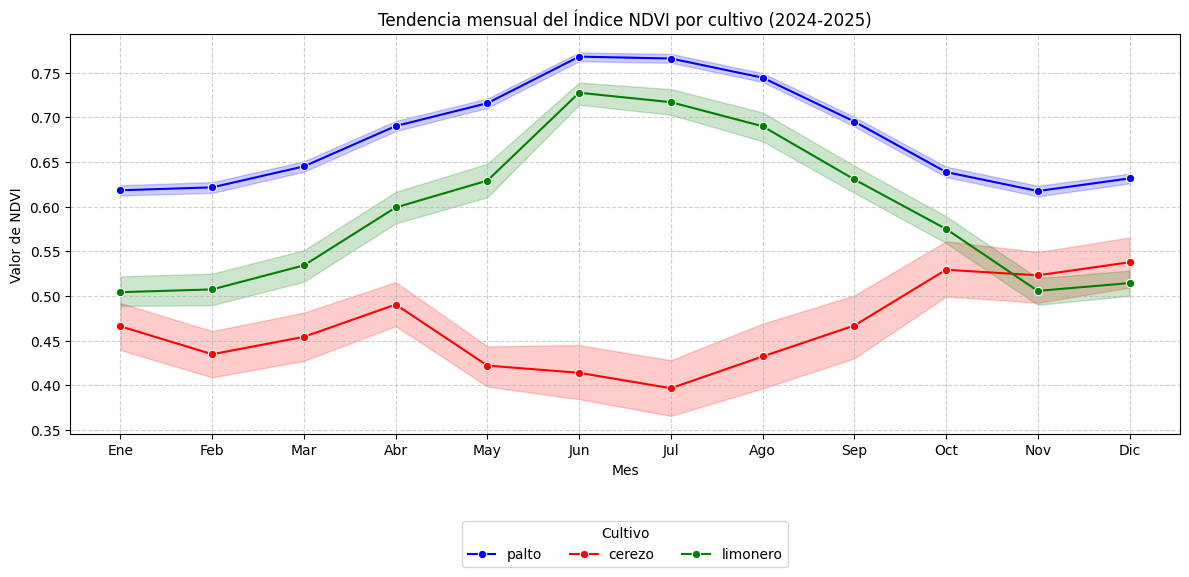

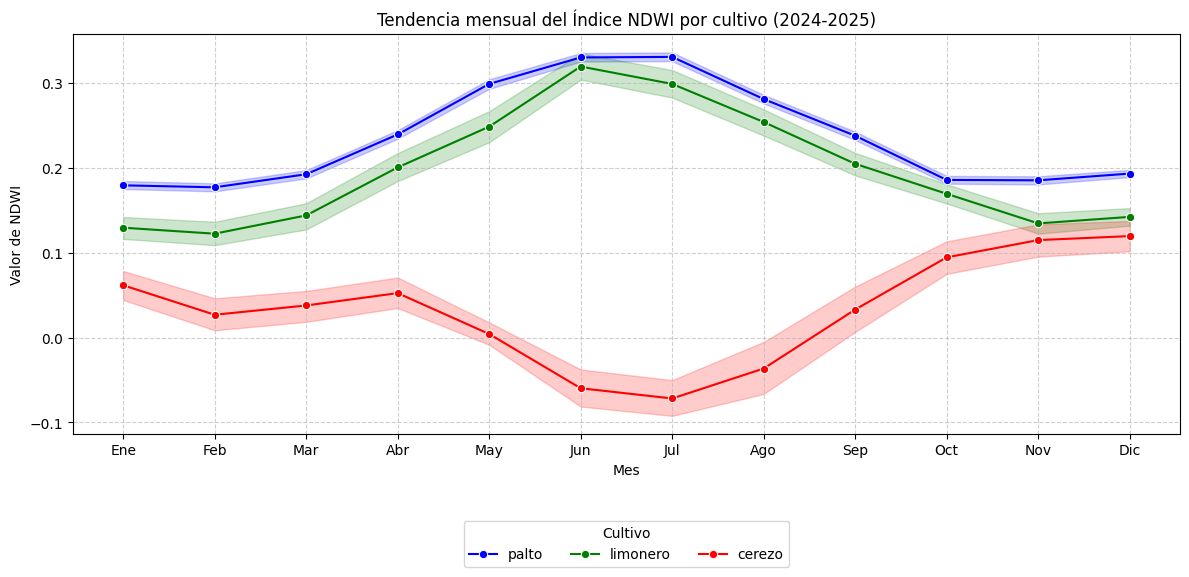

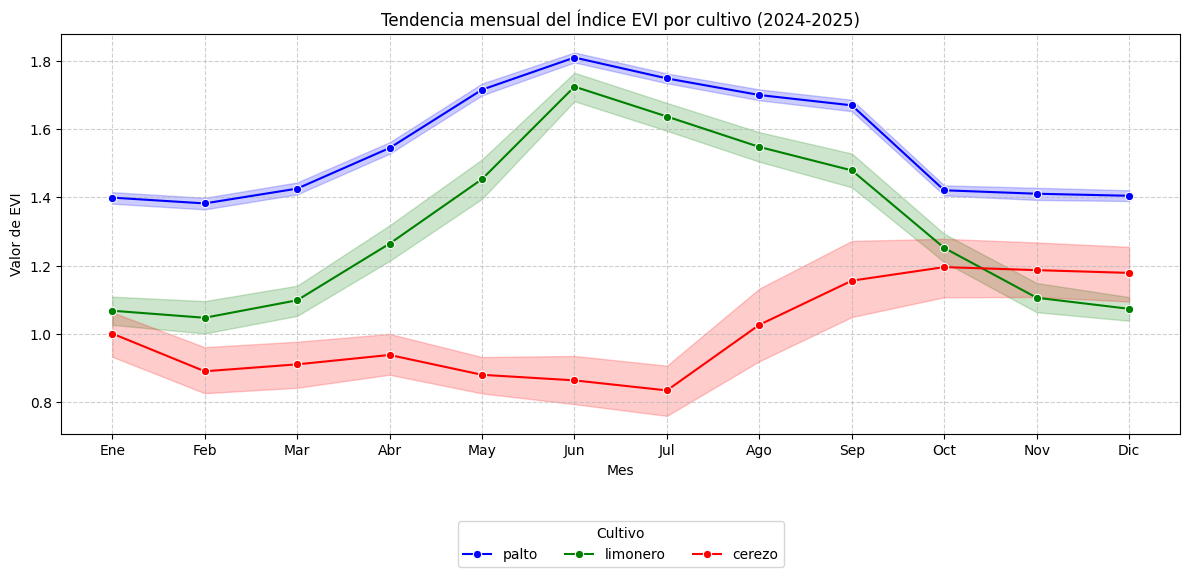

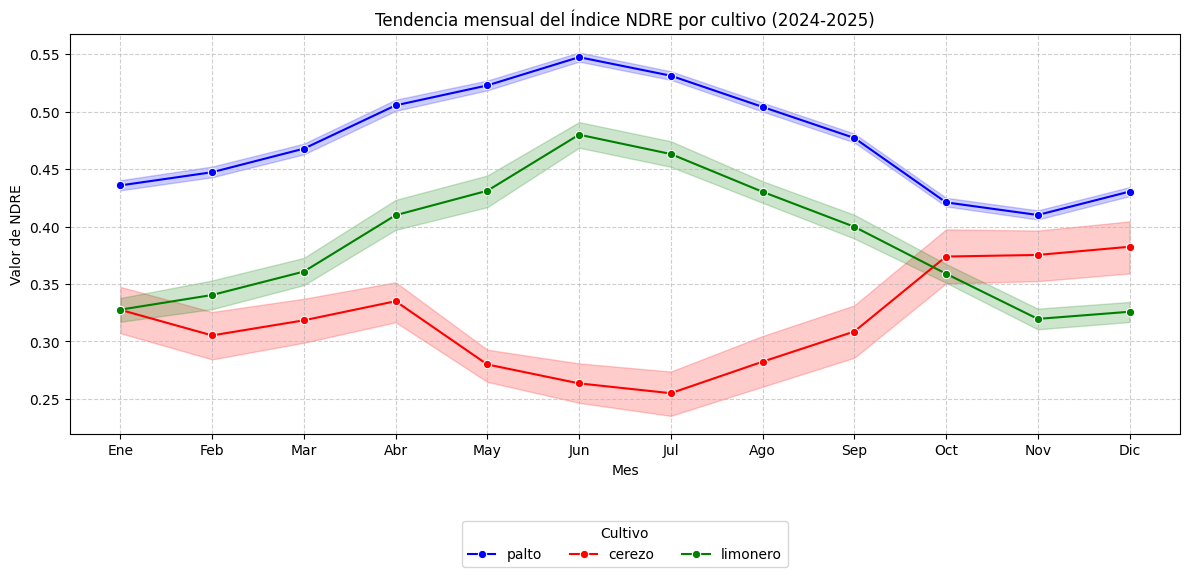

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convertir archivos de FeatureCollection a un DataFrame de pandas
training_df = geemap.ee_to_df(training)

# Eliminar la columna 'random' al no ser necesaria para la visualización
if 'random' in training_df.columns:
    training_df = training_df.drop(columns=['random'])

# Corresponder los valores numéricos al cultivo correspondiente para la leyenda
cultivo_map = {1: 'cerezo', 2: 'limonero', 3: 'palto'}
training_df['cultivo'] = training_df['cultivo'].map(cultivo_map)

# Identificar las columnas de los índices y los meses (NDVI_01, NDVI_02, ..., NDRE_12)
index_types = ['NDVI', 'NDWI', 'EVI', 'NDRE']

# Preparar el DataFrame para para tener una columna de valor y una de índice/mes
df_melted = pd.DataFrame()

for index_type in index_types:
    # Seleccionar columnas para el índice actual (NDVI_01, NDVI_02, ...)
    cols_to_melt = [col for col in training_df.columns if col.startswith(index_type + '_')]

    if cols_to_melt:
        df_temp = training_df[['cultivo'] + cols_to_melt]
        df_temp_melted = df_temp.melt(id_vars=['cultivo'],
                                       var_name='index_month',
                                       value_name='value')

        # Extraer el tipo de índice y el mes
        df_temp_melted['index_type'] = df_temp_melted['index_month'].apply(lambda x: x.split('_')[0])
        df_temp_melted['month'] = df_temp_melted['index_month'].apply(lambda x: int(x.split('_')[1]))

        df_melted = pd.concat([df_melted, df_temp_melted])

# Ordenar el eje X en orden cronológico (meses)
df_melted = df_melted.sort_values(by='month')

# Definir una paleta de colores fija para los cultivos
custom_palette = {'cerezo': 'red', 'limonero': 'green', 'palto': 'blue'}

for index_type in index_types:
    plt.figure(figsize=(12, 6))

    subset_df = df_melted[df_melted['index_type'] == index_type]

    if not subset_df.empty:
        sns.lineplot(data=subset_df,
                     x='month',
                     y='value',
                     hue='cultivo',
                     marker='o',
                     palette=custom_palette) # Aplicar la paleta de colores fija

        plt.title(f'Tendencia mensual del Índice {index_type} por cultivo (2024-2025)')
        plt.xlabel('Mes')
        plt.ylabel(f'Valor de {index_type}')
        plt.xticks(range(1, 13), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend(title='Cultivo', bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=len(custom_palette)) # Modificado para colocar la leyenda abajo y horizontal
        plt.tight_layout()
        plt.show()
    else:
        print(f"No hay datos para el índice {index_type} en el DataFrame.")

# 06. Validación

In [ ]:
# Obtención de valores aleatorios para dividir las muestras de entrenamiento y validación
training_random = training.randomColumn()

In [ ]:
# Filtrar y dividir las muestras
train_set = training_random.filter(
    ee.Filter.lt(
        'random',
        0.7
    )
)

test_set = training_random.filter(
    ee.Filter.gte(
        'random',
        0.7
    )
)

In [ ]:
# Entrenamiento del modelo con la muestra de entrenamiento
rf = ee.Classifier.smileRandomForest(
    500
).train(
    train_set,
    'cultivo',
    variables
)

In [ ]:
# Validación y obtención de estadísticos para la evaluación del modelo
validated = test_set.classify(rf)

matrix = validated.errorMatrix(
    'cultivo',
    'classification'
)

print("Matriz de confusión:", matrix.getInfo())

producer_accuracy = matrix.producersAccuracy()
print("Precisión del productor:", producer_accuracy.getInfo())

kappa_coefficient = matrix.kappa()
print("Coeficiente Kappa:", kappa_coefficient.getInfo())

print("Accuracy:", matrix.accuracy().getInfo())

print("Conteo de muestras por categoría de cultivo en el conjunto de entrenamiento:")
display(training_df['cultivo'].value_counts())

Matriz de confusión: [[0, 0, 0, 0], [0, 17, 0, 1], [0, 0, 27, 46], [0, 2, 2, 689]]
Precisión del productor: [[0], [0.9444444444444444], [0.3698630136986301], [0.9942279942279942]]
Coeficiente Kappa: 0.6085717921859245
Accuracy: 0.9349489795918368
Conteo de muestras por categoría de cultivo en el conjunto de entrenamiento:


,count
cultivo,
palto,2358
limonero,228
cerezo,83


In [ ]:
# 10. Extraer la información generada para los polígonos de FTW
ftw_features = feature_stack.reduceRegions(
    collection=ftw_ee,
    reducer=ee.Reducer.mean(),
    scale=10
)

In [ ]:
# 11. Asignar la categoría resultante en función de la votación del modelo
ftw_clean = ftw_features.filter(
    ee.Filter.notNull(
        feature_stack.bandNames()
    )
)

ftw_classified = ftw_clean.classify(rf)

# 07. Exportar

In [ ]:
# Solicitar a GEE que genere una capa vectorial con la información final
task = ee.batch.Export.table.toDrive(
    collection=ftw_classified,
    description='FTW5_RF_2025',
    folder='Evaluacion3_SIG',
    fileFormat='SHP'
)

task.start()